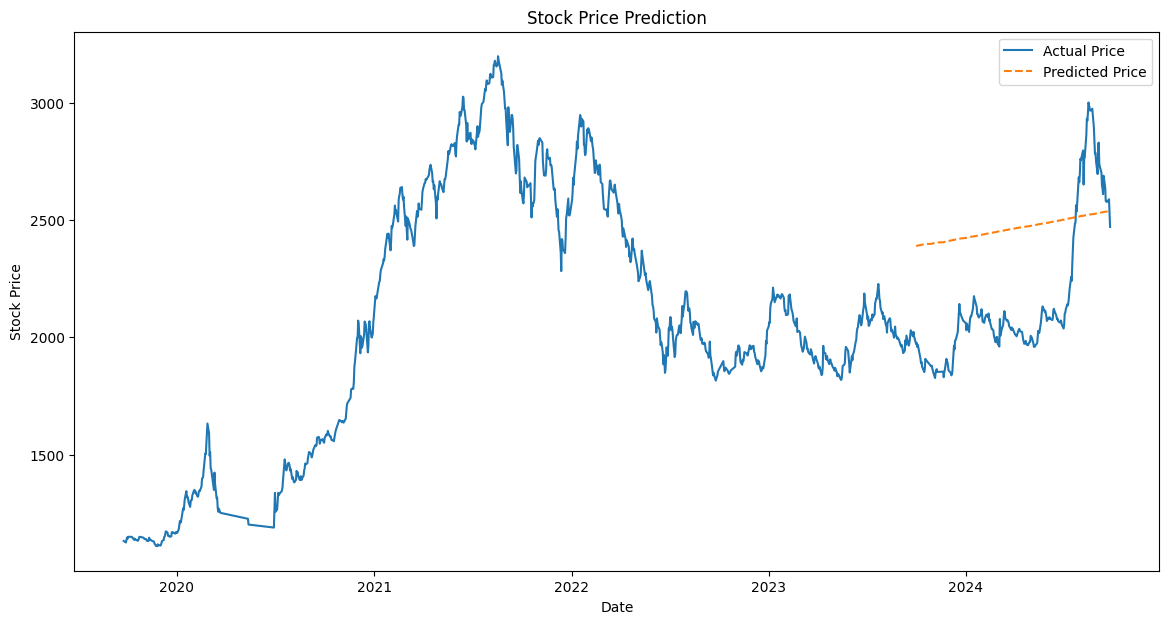

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Step 1: Load the Data
# Assuming you have a CSV file with 'Date' and 'Close' columns
data = pd.read_csv('stock_prices.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Step 2: Train the Model
# For simplicity, let's use a linear regression model
X = np.array(range(len(data))).reshape(-1, 1)  # Using index as feature
y = data['Close'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
model = LinearRegression()
model.fit(X_train, y_train)

# Step 3: Make Predictions
predictions = model.predict(X_test)

# Step 4: Prepare the Data for Plotting
predicted_dates = data.index[len(X_train):]
predicted_df = pd.DataFrame({'Date': predicted_dates, 'Predicted': predictions})
predicted_df.set_index('Date', inplace=True)

# Combine actual and predicted prices
combined_df = data[['Close']].join(predicted_df, how='outer')

# Step 5: Plot the Data
plt.figure(figsize=(14, 7))
plt.plot(combined_df.index, combined_df['Close'], label='Actual Price')
plt.plot(combined_df.index, combined_df['Predicted'], label='Predicted Price', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediction')
plt.legend()
plt.show()